In [ ]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent
SRC_PATH = PROJECT_ROOT / "src"
sys.path.append(str(SRC_PATH))

from  preprocessing import clean_training_dataframe
from models import (
    build_baseline_model,
    build_random_forest_model,
    get_feature_importance
)

import evaluation
import models

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import make_scorer, f1_score

## 1. Carga de los datos


In [63]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

SRC_PATH = PROJECT_ROOT / "src"
DATA_PATH = PROJECT_ROOT / "data" / "sesiones_surf.csv"
MODELS_PATH = PROJECT_ROOT / "models"

sys.path.append(str(SRC_PATH))

PROJECT_ROOT

PosixPath('/home/irati/surf-session/surf-session-classifier')

In [64]:
# Cargamos los datos

df = pd.read_csv(DATA_PATH)

df.head()
# 

,id_sesion,fecha,spot,altura_ola_m,periodo_s,direccion_swell,viento_kmh,direccion_viento,marea,temp_agua,num_surfistas,valoracion,buena_sesion
0,S100806,2023-11-23,SOMO,1.18,16.9,273,13.1,NW,baja,18.5,33,4,No
1,S100875,2023-06-18,Somo,1.79,5.3,317,9.5,NaN,media,16.6,27,4,No
2,S100206,2024-05-28,Pantin,1.70,12.8,332,28.8,S,baja,18.2,19,4,Yes
3,S101506,2023-01-21,Rodiles,1.78,9.0,326,13.9,N,alta,15.2,25,3,No
4,S101520,2023-01-15,Rodiles,0.57,7.7,354,17.3,N,baja,21.5,15,3,No


#### Preparación de los datos

Antes de entrenar los modelos se aplica una limpieza inicial al dataframe completo. Esta limpieza elimina duplicados y registros con valores claramente anómalos en la altura de ola.

El resto del preprocesado, como imputaciones, codificación de variables categóricas y escalado, se mantiene dentro del `Pipeline`. Esto es importante para evitar fuga de información entre entrenamiento y test.

In [65]:
TARGET = "buena_sesion"

df_clean = clean_training_dataframe(df)

df_clean["fecha"] = pd.to_datetime(df_clean["fecha"], errors="coerce")
df_clean = df_clean.sort_values("fecha").reset_index(drop=True)

df_clean.head()

Duplicados eliminados: 12
Filas eliminadas por altura_ola_m = 99: 8


,id_sesion,fecha,spot,altura_ola_m,periodo_s,direccion_swell,viento_kmh,direccion_viento,marea,temp_agua,num_surfistas,valoracion,buena_sesion
0,S100905,2022-09-01,Pantin,1.69,12.2,334,NaN,S,baja,16.4,32,4,Yes
1,S100301,2022-09-01,Pantin,3.01,6.7,359,4.9,N,media,16.1,34,4,No
2,S101005,2022-09-01,Rodiles,0.99,11.7,299,10.3,N,media,21.8,18,4,No
3,S101362,2022-09-02,Sopela,1.59,7.1,254,9.1,N,alta,14.2,18,4,No
4,S101753,2022-09-02,sopela,1.33,12.0,329,5.6,S,baja,16.9,25,4,Yes


In [66]:
# Separamos predictor y predictando
X = df_clean.drop(columns=[TARGET])

y = df_clean[TARGET].map({
    "No": 0,
    "Yes": 1,
})

if y.isna().any():
    raise ValueError("La variable objetivo contiene valores distintos de 'Yes' y 'No'.")

X.head()

,id_sesion,fecha,spot,altura_ola_m,periodo_s,direccion_swell,viento_kmh,direccion_viento,marea,temp_agua,num_surfistas,valoracion
0,S100905,2022-09-01,Pantin,1.69,12.2,334,NaN,S,baja,16.4,32,4
1,S100301,2022-09-01,Pantin,3.01,6.7,359,4.9,N,media,16.1,34,4
2,S101005,2022-09-01,Rodiles,0.99,11.7,299,10.3,N,media,21.8,18,4
3,S101362,2022-09-02,Sopela,1.59,7.1,254,9.1,N,alta,14.2,18,4
4,S101753,2022-09-02,sopela,1.33,12.0,329,5.6,S,baja,16.9,25,4


In [67]:
def temporal_train_test_split(X, y, train_size=0.8):
    """
    Divide los datos respetando el orden temporal.

    El primer porcentaje de datos se usa para entrenamiento y el resto,
    más reciente, para test.
    """

    split_idx = int(len(X) * train_size)

    X_train = X.iloc[:split_idx]
    X_test = X.iloc[split_idx:]

    y_train = y.iloc[:split_idx]
    y_test = y.iloc[split_idx:]

    return X_train, X_test, y_train, y_test

In [68]:
# Dividimos el dataset en train y test
X_train, X_test, y_train, y_test = temporal_train_test_split(
    X,
    y,
    train_size=0.8,
)

print("Tamaño train:", X_train.shape)
print("Tamaño test:", X_test.shape)

Tamaño train: (1593, 12)
Tamaño test: (399, 12)


In [69]:
print("Periodo de entrenamiento:")
print(
    pd.to_datetime(X_train["fecha"]).min().date(),
    "-",
    pd.to_datetime(X_train["fecha"]).max().date(),
)

print("\nPeriodo de test:")
print(
    pd.to_datetime(X_test["fecha"]).min().date(),
    "-",
    pd.to_datetime(X_test["fecha"]).max().date(),
)

Periodo de entrenamiento:
2022-09-01 - 2024-08-10

Periodo de test:
2024-08-10 - 2025-02-16


In [70]:
train_dist = y_train.value_counts(normalize=True).rename(index={0: "No", 1: "Yes"})
test_dist = y_test.value_counts(normalize=True).rename(index={0: "No", 1: "Yes"})

class_distribution = pd.DataFrame({
    "train": train_dist,
    "test": test_dist,
}).round(3)

class_distribution

,train,test
buena_sesion,,
No,0.718,0.729
Yes,0.282,0.271


### Modelo baseline

Vamos a entrenar un modelo baseline para comparar posteriormente los modelos con este.



In [71]:
baseline_model = build_baseline_model()

baseline_model.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.72,0.28]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](12,)","['id_sesion','fecha','spot',...,'temp_agua','num_surfistas','valoracion']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,12
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [77]:
baseline_results = evaluate_train_test(
    baseline_model,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name="Baseline",
)

baseline_results

===== Baseline - Train =====
Accuracy:          0.718
Balanced accuracy: 0.500
Precision Yes:     0.000
Recall Yes:        0.000
F1 Yes:            0.000
ROC AUC:           0.500

Classification report:
              precision    recall  f1-score   support

          No       0.72      1.00      0.84      1143
         Yes       0.00      0.00      0.00       450

    accuracy                           0.72      1593
   macro avg       0.36      0.50      0.42      1593
weighted avg       0.51      0.72      0.60      1593



===== Baseline - Test =====
Accuracy:          0.729
Balanced accuracy: 0.500
Precision Yes:     0.000
Recall Yes:        0.000
F1 Yes:            0.000
ROC AUC:           0.500

Classification report:
              precision    recall  f1-score   support

          No       0.73      1.00      0.84       291
         Yes       0.00      0.00      0.00       108

    accuracy                           0.73       399
   macro avg       0.36      0.50      0.42     

,accuracy,balanced_accuracy,precision_yes,recall_yes,f1_yes,roc_auc
train,0.718,0.5,0.0,0.0,0.0,0.5
test,0.729,0.5,0.0,0.0,0.0,0.5


### Random Forest

Para el siguiente modelo elegimos un Random Forest. El random forest nos permite reducir la variabilidad de un único árbol y generaliza mejor. Nos permitira capturar interacciones entre spot, viento etc. . Podemos hacer un remuestreo de las clases permitiendo balancearlas, y nos permite mantener un poco la interpretabilidad. 

In [97]:
rf_model = build_random_forest_model(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=10,
    class_weight="balanced",
)

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('cleaner', ...), ('column_transformer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value


In [98]:
rf_results = evaluate_train_test(rf_model,X_train,y_train,
                                 X_test,y_test,model_name="Random Forest",)

rf_results

===== Random Forest - Train =====
Accuracy:          0.812
Balanced accuracy: 0.837
Precision Yes:     0.616
Recall Yes:        0.893
F1 Yes:            0.729
ROC AUC:           0.934

Classification report:
              precision    recall  f1-score   support

          No       0.95      0.78      0.86      1143
         Yes       0.62      0.89      0.73       450

    accuracy                           0.81      1593
   macro avg       0.78      0.84      0.79      1593
weighted avg       0.85      0.81      0.82      1593



===== Random Forest - Test =====
Accuracy:          0.764
Balanced accuracy: 0.795
Precision Yes:     0.541
Recall Yes:        0.861
F1 Yes:            0.664
ROC AUC:           0.895

Classification report:
              precision    recall  f1-score   support

          No       0.93      0.73      0.82       291
         Yes       0.54      0.86      0.66       108

    accuracy                           0.76       399
   macro avg       0.74      0.79     

,accuracy,balanced_accuracy,precision_yes,recall_yes,f1_yes,roc_auc
train,0.812,0.837,0.616,0.893,0.729,0.934
test,0.764,0.795,0.541,0.861,0.664,0.895


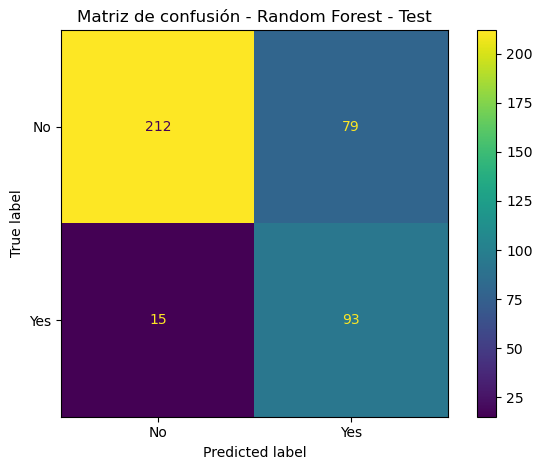

In [99]:
plot_confusion_matrix(
    rf_model, X_test, y_test,
    model_name="Random Forest - Test",
)

In [100]:
comparison_test = pd.DataFrame({
    "Baseline": baseline_results.loc["test"],
    "Decision Tree": tree_results.loc["test"],
    "Random Forest": rf_results.loc["test"],
}).T

comparison_test

,accuracy,balanced_accuracy,precision_yes,recall_yes,f1_yes,roc_auc
Baseline,0.729,0.500,0.000,0.000,0.000,0.500
Decision Tree,0.744,0.778,0.517,0.852,0.643,0.858
Random Forest,0.764,0.795,0.541,0.861,0.664,0.895


Para elegir los mejores hiperparámetros para el randomForest, vamos a hacer un GridSearchCV

In [115]:
rf_model = build_random_forest_model()

param_grid_rf = {
    "classifier__n_estimators": [300, 500, 1000],
    "classifier__max_depth": [None, 8, 12, 16],
    "classifier__min_samples_leaf": [1, 2, 5, 10],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__class_weight": ["balanced"],
}


In [116]:
temporal_cv = TimeSeriesSplit(n_splits=5)
f1_scorer = make_scorer(f1_score, zero_division=0)

In [117]:
grid_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    scoring=f1_scorer,
    cv=temporal_cv,
    n_jobs=-1,
    verbose=2,
)

In [118]:
grid_rf.fit(X_train, y_train)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


[CV] END classifier__class_weight=balanced, classifier__max_depth=None, classifier__min_samples_leaf=1, classifier__min_samples_split=2, classifier__n_estimators=300; total time=   9.1s
[CV] END classifier__class_weight=balanced, classifier__max_depth=None, classifier__min_samples_leaf=1, classifier__min_samples_split=2, classifier__n_estimators=300; total time=  10.8s
[CV] END classifier__class_weight=balanced, classifier__max_depth=None, classifier__min_samples_leaf=1, classifier__min_samples_split=2, classifier__n_estimators=300; total time=  11.0s[CV] END classifier__class_weight=balanced, classifier__max_depth=None, classifier__min_samples_leaf=1, classifier__min_samples_split=2, classifier__n_estimators=300; total time=  11.1s

[CV] END classifier__class_weight=balanced, classifier__max_depth=None, classifier__min_samples_leaf=1, classifier__min_samples_split=2, classifier__n_estimators=300; total time=  12.7s
[CV] END classifier__class_weight=balanced, classifier__max_depth=None

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__class_weight': ['balanced'], 'classifier__max_depth': [None, 8, ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(f...ro_division=0)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this speci

In [122]:
print("Mejores hiperparámetros:")
print(grid_rf.best_params_)

print("\nMejor F1 medio en validación temporal:")
print(round(grid_rf.best_score_, 3))

Mejores hiperparámetros:
{'classifier__class_weight': 'balanced', 'classifier__max_depth': 12, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 500}

Mejor F1 medio en validación temporal:
0.717


In [124]:
#Nos quedamos con el mejor modelo
best_rf_model = grid_rf.best_estimator_

rf_tuned_results = evaluate_train_test(
    best_rf_model,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name="Random Forest tuned",
)

rf_tuned_results

===== Random Forest tuned - Train =====
Accuracy:          0.941
Balanced accuracy: 0.958
Precision Yes:     0.830
Recall Yes:        0.996
F1 Yes:            0.905
ROC AUC:           0.996

Classification report:
              precision    recall  f1-score   support

          No       1.00      0.92      0.96      1143
         Yes       0.83      1.00      0.91       450

    accuracy                           0.94      1593
   macro avg       0.91      0.96      0.93      1593
weighted avg       0.95      0.94      0.94      1593



===== Random Forest tuned - Test =====
Accuracy:          0.830
Balanced accuracy: 0.834
Precision Yes:     0.641
Recall Yes:        0.843
F1 Yes:            0.728
ROC AUC:           0.905

Classification report:
              precision    recall  f1-score   support

          No       0.93      0.82      0.88       291
         Yes       0.64      0.84      0.73       108

    accuracy                           0.83       399
   macro avg       0.79   

,accuracy,balanced_accuracy,precision_yes,recall_yes,f1_yes,roc_auc
train,0.941,0.958,0.830,0.996,0.905,0.996
test,0.830,0.834,0.641,0.843,0.728,0.905


In [125]:
grid_results_rf = pd.DataFrame(grid_rf.cv_results_)

grid_results_rf[
    [
        "mean_test_score",
        "std_test_score",
        "param_classifier__n_estimators",
        "param_classifier__max_depth",
        "param_classifier__min_samples_leaf",
        "param_classifier__min_samples_split",
        "param_classifier__class_weight",
    ]
].sort_values("mean_test_score", ascending=False).head(10)

,mean_test_score,std_test_score,param_classifier__n_estimators,param_classifier__max_depth,param_classifier__min_samples_leaf,param_classifier__min_samples_split,param_classifier__class_weight
85,0.717288,0.042012,500,12,2,5,balanced
118,0.715683,0.047105,500,16,2,2,balanced
114,0.715576,0.042667,300,16,1,10,balanced
57,0.714690,0.060063,300,8,5,5,balanced
60,0.714690,0.060063,300,8,5,10,balanced
54,0.714690,0.060063,300,8,5,2,balanced
79,0.713356,0.044005,500,12,1,10,balanced
6,0.713326,0.042217,300,None,1,10,balanced
115,0.713270,0.044681,500,16,1,10,balanced
37,0.713207,0.044443,500,8,1,2,balanced
